#### Error Mitigated Noisy Quantum SVM - Lung Cancer

This notebook adds **Zero Noise Extrapolation (ZNE)** on top of the noisy QSVM flow.

In [2]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

Qiskit: 1.4.4
Aer: 0.17.2
QML: 0.8.4


In [3]:
# To ensure reproducibility of results
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 12345

In [4]:
# Imports
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [5]:
# --- Qiskit Imports ---
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

from qiskit_aer.primitives import SamplerV2 as AerSampler

from qiskit.circuit.library import ZZFeatureMap

# Qiskit machine learning
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# For transpilation
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [6]:
# Load data first
lung_cancer_column_names = ['label'] + [f'attr_{i}' for i in range(1, 57)]
file_path_lung = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\lung+cancer\lung-cancer.data'

# reads the data, treating "?" as missing values
df_lung = pd.read_csv(file_path_lung, header=None, names=lung_cancer_column_names, na_values=['?'])

print(f"Original shape of Lung Cancer data: {df_lung.shape}")

Original shape of Lung Cancer data: (32, 57)


In [7]:
# Mode imputation for missing values
modes = df_lung.mode().iloc[0]
df_lung.fillna(modes, inplace=True)

# Then check if all Nan are gone
print(f"Total missing values after imputation: {df_lung.isnull().sum().sum()}\n")

Total missing values after imputation: 0



In [8]:
df_lung['label_binary'] = df_lung['label'].apply(lambda x: 0 if x == 1 else 1)

In [9]:
X_lung = df_lung.drop(['label', 'label_binary'], axis=1)
y_lung_binary = df_lung['label_binary']

In [10]:
# Train-test split
X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lung, y_lung_binary, test_size=0.3, random_state=42, stratify=y_lung_binary
)

In [11]:
# One-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_lc_encoded = pd.DataFrame(encoder.fit_transform(X_train_lc), columns=encoder.get_feature_names_out())
X_test_lc_encoded = pd.DataFrame(encoder.transform(X_test_lc), columns=encoder.get_feature_names_out())

In [12]:
# Feature selection with Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0: 
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_scores = {col: cramers_v(X_train_lc_encoded[col], y_train_lc) for col in X_train_lc_encoded.columns}
cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)

N_FEATURES_TO_SELECT = 10
top_features = cramers_series.head(N_FEATURES_TO_SELECT).index.tolist()

X_train_lc_final = X_train_lc_encoded[top_features]
X_test_lc_final = X_test_lc_encoded[top_features]

print("--- Data Preprocessing Complete ---")
print(f"Final training data shape: {X_train_lc_final.shape}")
print(f"Final testing data shape: {X_test_lc_final.shape}\n")

--- Data Preprocessing Complete ---
Final training data shape: (22, 10)
Final testing data shape: (10, 10)



##### Setup Noise Model with Scaling for ZNE

In [13]:
# Noise Model implementation (Depolarizing error and Readout Error)
print("--- Setting up Noise Model ---")
# Error rates (realistic, not too high)
p_gate_1q = 0.001   # 0.1% error for single-qubit gates (u1, u2, u3)
p_gate_2q = 0.01    # 1.0% error for two-qubit gates (cx)
p_readout = 0.02    # 2.0% chance of wrong measurement

def get_scaled_noise_model(scale_factor=1.0):
    """Build a noise model with scaled error probabilities for ZNE."""
    noise_model = NoiseModel()
    
    # Scale probabilities: p_new = 1 - (1-p)^scale
    p_1q_scaled = 1 - (1 - p_gate_1q)**scale_factor
    p_2q_scaled = 1 - (1 - p_gate_2q)**scale_factor
    p_readout_scaled = 1 - (1 - p_readout)**scale_factor
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_1q_scaled, 1), ['u1', 'u2', 'u3'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_2q_scaled, 2), ['cx'])
    
    readout_error = ReadoutError([[1 - p_readout_scaled, p_readout_scaled], [p_readout_scaled, 1 - p_readout_scaled]])
    noise_model.add_all_qubit_readout_error(readout_error, ['measure'])
    
    return noise_model

# Base noise model (scale=1)
noise_model = get_scaled_noise_model(1.0)
print("Base noise model created.")

--- Setting up Noise Model ---
Base noise model created.


In [14]:
# Create Backends and Samplers for ZNE (scale 1.0 and 3.0)
noisy_backend_1 = AerSimulator(
    noise_model=get_scaled_noise_model(1.0),
    seed_simulator=12345,
)
noisy_backend_3 = AerSimulator(
    noise_model=get_scaled_noise_model(3.0),
    seed_simulator=12345,
)

sampler_1 = AerSampler.from_backend(
    backend=noisy_backend_1,
    default_shots=8192,
)
sampler_3 = AerSampler.from_backend(
    backend=noisy_backend_3,
    default_shots=8192,
)

print("Noisy SamplerV2 (scale 1 and 3) ready for ZNE!")

Noisy SamplerV2 (scale 1 and 3) ready for ZNE!


In [15]:
# Transpilation pass manager
pm_1 = generate_preset_pass_manager(optimization_level=1, backend=noisy_backend_1)
pm_3 = generate_preset_pass_manager(optimization_level=1, backend=noisy_backend_3)

print("Pass managers ready.")

Pass managers ready.


##### Quantum Kernel Implementation (Two scales for ZNE)

In [16]:
feature_dim = N_FEATURES_TO_SELECT
fm = ZZFeatureMap(feature_dimension=feature_dim, reps=2, entanglement='linear')

# Fidelity with noisy sampler and transpilation - Scale 1
fidelity_1 = ComputeUncompute(sampler=sampler_1, pass_manager=pm_1)
quantum_kernel_1 = FidelityQuantumKernel(fidelity=fidelity_1, feature_map=fm)

# Fidelity with noisy sampler and transpilation - Scale 3
fidelity_3 = ComputeUncompute(sampler=sampler_3, pass_manager=pm_3)
quantum_kernel_3 = FidelityQuantumKernel(fidelity=fidelity_3, feature_map=fm)

print("Quantum Kernels (scale 1 and 3) created.")

Quantum Kernels (scale 1 and 3) created.


In [17]:
# Compute Kernel Matrices for ZNE
print("Computing kernel matrix at scale 1.0...")
matrix_train_1 = quantum_kernel_1.evaluate(x_vec=X_train_lc_final)
matrix_test_1 = quantum_kernel_1.evaluate(x_vec=X_test_lc_final, y_vec=X_train_lc_final)

print("Computing kernel matrix at scale 3.0...")
matrix_train_3 = quantum_kernel_3.evaluate(x_vec=X_train_lc_final)
matrix_test_3 = quantum_kernel_3.evaluate(x_vec=X_test_lc_final, y_vec=X_train_lc_final)

print("Kernel matrices computed.")

Computing kernel matrix at scale 1.0...
Computing kernel matrix at scale 3.0...
Kernel matrices computed.


In [18]:
# Zero Noise Extrapolation
# Richardson extrapolation with scales [1, 3]:
# K_mitigated = 1.5 * K(scale=1) - 0.5 * K(scale=3)

matrix_train_zne = 1.5 * matrix_train_1 - 0.5 * matrix_train_3
matrix_test_zne = 1.5 * matrix_test_1 - 0.5 * matrix_test_3

print("ZNE extrapolation complete.")

ZNE extrapolation complete.


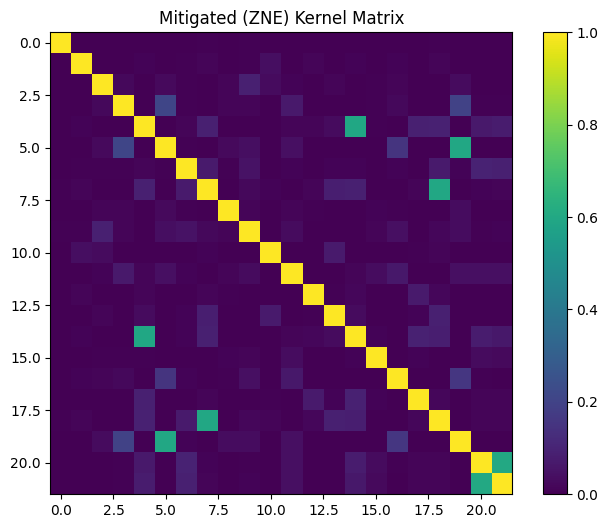

In [19]:
# Plotting mitigated kernel matrix
plt.figure(figsize=(8, 6))
plt.imshow(matrix_train_zne, cmap='viridis')
plt.title("Mitigated (ZNE) Kernel Matrix")
plt.colorbar()
plt.show()

In [ ]:
# Training with precomputed mitigated kernel
print("--- Training Mitigated QSVC (Lung Cancer) ---")
start_time = time.time()

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
}

# Use cross-validation suitable for small/imbalanced data
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid search on SVC with precomputed kernel
grid_search = GridSearchCV(
    SVC(kernel='precomputed', class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1
)

--- Training Mitigated QSVC (Lung Cancer) ---


In [21]:
grid_search.fit(matrix_train_zne, y_train_lc)
qsvc_mitigated = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
end_time = time.time()
print(f"QSVC training finished in {end_time - start_time:.2f} seconds.")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'C': 1}
QSVC training finished in 0.13 seconds.


In [22]:
y_train_pred = qsvc_mitigated.predict(matrix_train_zne)
train_accuracy = accuracy_score(y_train_lc, y_train_pred)

y_test_pred = qsvc_mitigated.predict(matrix_test_zne)
test_accuracy = accuracy_score(y_test_lc, y_test_pred)

generalization_gap = abs(train_accuracy - test_accuracy)

print(f"\n--- Mitigated (ZNE) QSVM Evaluation (Lung Cancer) ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"Generalization Gap: {generalization_gap:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test_lc, y_test_pred, zero_division=0))


--- Mitigated (ZNE) QSVM Evaluation (Lung Cancer) ---
Training Accuracy: 0.9545
Test Accuracy:     0.8000
Generalization Gap: 0.1545

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.78      1.00      0.88         7

    accuracy                           0.80        10
   macro avg       0.89      0.67      0.69        10
weighted avg       0.84      0.80      0.76        10

